## C S 329E HW 10

## Your Name Here (or your names here if you are pair programming)

 - Student Name:Odette Saenz
 - Student UT EID:oss286


 - Partner Name:Shruthi Garla
 - Partner UT EID:sg54464



# Clustering with K-means and DBSCAN

## Your name here (and your partner's name if you are working in a pair)

For this week's homework we are going explore two clustering methods:

  - K-Means, and
  - DBSCAN
  
As we discussed in lecture, k-means creates clusters based on a distance measure, and DBSCAN creates clusters based on the density of the points in the vicinity of the data.  Using small example data sets, we will implement both algorithms and visualize the results.

Even though the example data is small and 2 dimensional, write your helper functions to not assume a 2-D data set.  Your plotting code can reference the `x` and `y` column names from the sample data directly. 

Note that I have added a one or two lines of code to the questions to test your implementations. 

In [1]:
# Do not import anything else
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Part 1 : K-Means

In the first half of the homework, we will implement the Algorithm 7.1 "Basic K-means", and apply that algorithm to a small data set provided with the assignment in the `data_kmeans.csv` file. We will build up some helper functions along the way, test them, and put it all together to apply to our small example data set. 

In [2]:
# loading in our toy data
df_kmeans = pd.read_csv('data_kmeans.csv')

## Q1.1 - Write a function that returns `k` random rows from a data frame

To initialize the centroids, we pick `k` random points from a data frame.  Write a function `init_centroids( df_data, k )` that accepts two parameters: a data frame `df_data`, and an integer `k`, and returns the initial centroids for our k-means algorithm.  Note, we want the indices of the returned data frame to range from 0 - (k-1) so that we can use these as the centroid labels.  Use [pandas sample](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) method, and pass it the value of $42$ for `random_state`. 

In [3]:
def init_centroids( df_data, k ):
    # Select k random rows from the dataframe
    centroids = df_data.sample(n=k, random_state=42)
    return centroids

In [4]:
# Testing our init centroid function
df_centroids = init_centroids( df_kmeans, 7 )
df_centroids

,x,y
407,-0.633437,0.488756
444,-0.597736,0.632194
117,-0.635867,0.166613
30,-0.539351,-0.875532
415,-0.588597,0.293062
157,-0.127985,-0.136639
325,0.342579,0.211717


## Q1.2 - Write a function to assign every row in a data frame to a centroid 

Write a function, `assign_to_centroid`, that accepts two parameters: a data frame, `df_data`, that represents our data to be clustered, and the data frame, `df_centroids`, which is of length `k` and contains the current centroids for our clusters.  The functions returns a series of the same length of `df_data` that contains the index of the closest centroid in `df_centroid`.  Use Euclidean distance as your distance measure. 

For example, if a row of data contained the data point $(100,123)$ and the three centroids were in a data frame that had the following information:

  - Index 0 : (34,34)
  - Index 1 : (0,1)
  - Index 2 : (83,99)

The `assign_to_centroid` function would assign the index $2$ to that row of data. 

In [5]:
def assign_to_centroid(df_data, df_centroids):
    # Initialize an empty list to store the index of the closest centroid for each data point
    closest_centroids = []
    
    # Loop through each row in df_data
    for index, row in df_data.iterrows():
        # Calculate the Euclidean distance between the current data point and each centroid
        distances = np.linalg.norm(df_centroids - row.values, axis=1)
        
        # Find the index of the centroid with the minimum distance
        closest_centroid_index = distances.argmin()
        
        # Append the index of the closest centroid to the list
        closest_centroids.append(closest_centroid_index)
    
    # Return a pandas Series with the centroid indices
    return pd.Series(closest_centroids, index=df_data.index)

In [6]:
# Check how many data points were assigned to each centroid
s_centroid_assignment = assign_to_centroid( df_kmeans, df_centroids )
s_centroid_assignment.value_counts()

6    126
1     94
3     71
5     58
0     53
2     26
4     22
Name: count, dtype: int64

## Q1.3 - Write a function that recomputes the centroids

Write a function `compute_centroids` that takes two parameters: the data frame, `df_data` containing the data being clustered, and a series of the same length that contains the label of the assigned centroid for every row in df_data, `s_centroid_assignment`. The function will return the a data frame containing the centroids (mean) value for each unique centroid. 

Note that the indices in the returned data frame should correspond to the unique values in `s_centroid_assignment`.  For example, if I found the mean value of df_data using the slice corresponding to `s_centroid_assigment == 2`, then the centroid should be in the returned data frame at `.iloc[2]`. 


In [7]:
def compute_centroids(df_data, s_centroid_assignment):
    # Combine the data frame and the centroid assignments into one DataFrame
    df_data_with_labels = df_data.copy()
    df_data_with_labels['centroid'] = s_centroid_assignment
    
    # Group the data by the centroid label and calculate the mean of each group
    centroids = df_data_with_labels.groupby('centroid').mean()
    
    # Return the resulting DataFrame containing the new centroids
    return centroids

In [8]:
# Test it out
df_new_centroids = compute_centroids( df_kmeans, s_centroid_assignment)
df_new_centroids

,x,y
centroid,,
0,-0.715983,0.500552
1,-0.721574,0.708343
2,-0.738268,-0.113830
3,-0.696694,-0.699028
4,-0.546913,0.321364
5,-0.102365,-0.188876
6,0.523364,0.238569


## Q1.4 - Write a function that compares two centroid data frames

The stopping criterion for k-means is when our centroids have not moved since the last iteration.  Write a function `compare_centroids` that is given 2 centroid data frames, `df_centroid_a`, and `df_centroid_b` as parameters and returns `True` or `False` indicating if the centroids at each unique index in the data frame are equal. Use the [equals](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.equals.html) method to compare equality of pandas Series objects. 

In [9]:
def compare_centroids(df_centroid_a, df_centroid_b):
    # Use the equals method to compare the two data frames
    return df_centroid_a.equals(df_centroid_b)

In [10]:
# Test it out, should print True followed by False
print(compare_centroids( df_new_centroids, df_new_centroids ))
print(compare_centroids( df_new_centroids, df_centroids ))

True
False


## Q1.5 - Write a function that implements k-means

Write a function, `k_means`, that takes in as parameters 2 values, a data frame with values to cluster, `df_data`, and the number of clusters to form, `k`.  The function should return a series of data of the same length as `df_data` that contains the cluster assignment (an integer from 0 to (k-1)) for each row of data.  Use the helper functions defined in the prior questions. 

In [11]:
def k_means(df_data, k):
    # Initialize centroids
    centroids = init_centroids(df_data, k)
    
    # Variable to store previous centroids
    prev_centroids = None
    
    # Keep iterating until convergence
    while prev_centroids is None or not compare_centroids(centroids, prev_centroids):
        # Step 1: Assign each data point to the closest centroid
        s_centroid_assignment = assign_to_centroid(df_data, centroids)
        
        # Step 2: Recompute the centroids based on the assignments
        prev_centroids = centroids
        centroids = compute_centroids(df_data, s_centroid_assignment)
    
    # Return the final centroid assignments
    return s_centroid_assignment


In [12]:
# Call k_means with k = 5 to test
s_cluster_assignment = k_means( df_kmeans, 5)
s_cluster_assignment.value_counts()

0    178
3     89
2     74
4     63
1     46
Name: count, dtype: int64

## Q1.6 - Plot the results

Plot the points in the `df_kmeans` data frame using a 2-D scatter plot, with a different color for each cluster.  Use the cluster assignments from the previous problem (`s_cluster_assignments`).  Label your axes, and give the plot a title. 

In [13]:
def plot_clusters(df_data, s_cluster_assignments):
    # Create a scatter plot for each cluster
    plt.figure(figsize=(8, 6))
    
    # Loop through each unique cluster (from 0 to k-1)
    for cluster in s_cluster_assignments.unique():
        # Get the data points for the current cluster
        cluster_data = df_data[s_cluster_assignments == cluster]
        
        # Plot the points for the current cluster with a specific color
        plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], label=f'Cluster {cluster}')
    
    # Label axes and title
    plt.xlabel(df_data.columns[0])
    plt.ylabel(df_data.columns[1])
    plt.title('K-means Clustering Results')
    
    # Add a legend to identify each cluster
    plt.legend()
    
    # Show the plot
    plt.show()

# Part 2 : DBSCAN

## Q2.1 Load the Density Data and try K-means

Load in the data provided `data_dbscan.csv`, cluster it with k-means algorithm with $k=2$ and visualize the results with a scatter plot, where the color indicates cluster membership. Label your axes, and give the plot a title. 

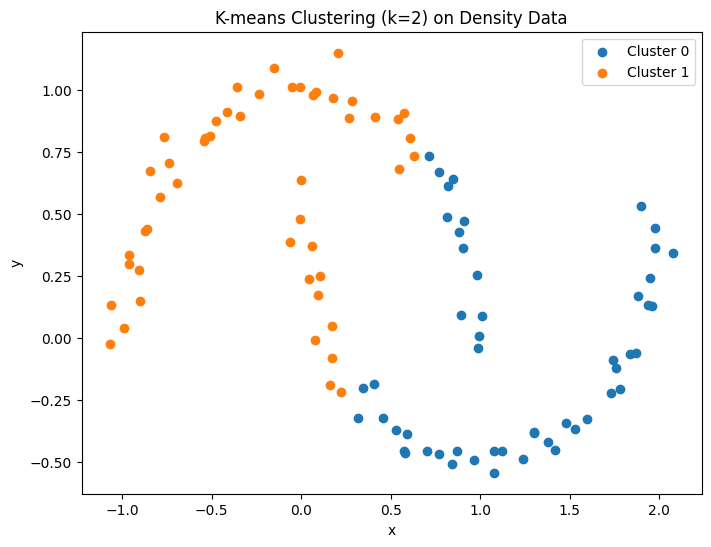

In [14]:
# Load the data
df_dbscan = pd.read_csv('data_dbscan.csv')

# Call k_means with k = 2
s_cluster_assignment = k_means(df_dbscan, 2)

# Plot the results
plt.figure(figsize=(8, 6))

# Loop through each unique cluster (0 and 1)
for cluster in s_cluster_assignment.unique():
    # Get the data points for the current cluster
    cluster_data = df_dbscan[s_cluster_assignment == cluster]
    
    # Plot the points for the current cluster with a specific color
    plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], label=f'Cluster {cluster}')

# Label axes and title
plt.xlabel(df_dbscan.columns[0])
plt.ylabel(df_dbscan.columns[1])
plt.title('K-means Clustering (k=2) on Density Data')

# Add a legend to identify each cluster
plt.legend()

# Show the plot
plt.show()

## Q2.2 Write function to Implement Range Query

Using the [pseudo-code](https://en.wikipedia.org/wiki/DBSCAN#Algorithm) on wikipedia, implement RangeQuery.

```
RangeQuery(DB, distFunc, Q, eps) {
    Neighbors N := empty list
    for each point P in database DB {                      /* Scan all points in the database */
        if distFunc(Q, P) ≤ eps then {                     /* Compute distance and check epsilon */
            N := N ∪ {P}                                   /* Add to result */
        }
    }
    return N
}
```

The "DB" parameter is a data frame, `df_data` containing all of the points in our data set, the "distFunc" is set as Euclidean distance thus should not be passed in, the point "Q", is represented by the index of the data frame, `q_index`, where `df_data.iloc[q_index]` is the actual point, and `eps` is a floating point value that indicates the radius from the point "Q" to search for neighbors.  The function will return the slice of `df_data` of all points within `eps` distance of "Q" (including "Q").  The indices on the slice should be preserved (do not reset_index).  

In [15]:
import numpy as np

def range_query(df_data, q_index, eps):
    # Get the point Q from the given index
    point_q = df_data.iloc[q_index]
    
    # Initialize an empty list to store the neighbors
    neighbors = []
    
    # Loop through each point in the dataframe to compute the Euclidean distance
    for idx, point in df_data.iterrows():
        # Compute the Euclidean distance between point Q and the current point
        distance = np.linalg.norm(point_q - point)
        
        # If the distance is less than or equal to eps, add the point to the neighbors list
        if distance <= eps:
            neighbors.append(idx)
    
    # Return the slice of df_data containing all neighbors (including Q itself)
    return df_data.loc[neighbors]

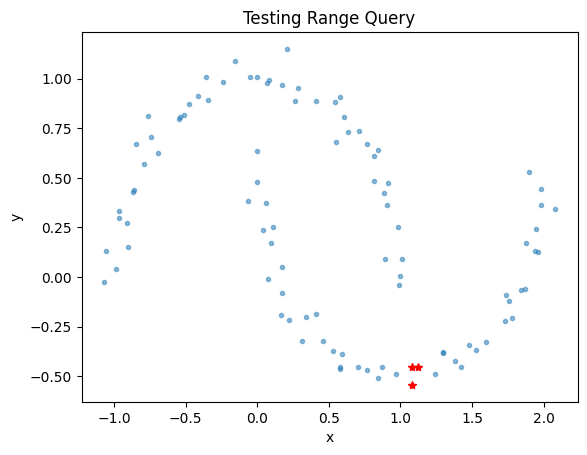

In [16]:
# Test it out
df_n = range_query( df_dbscan, 0, 0.1 )
plt.plot( df_dbscan['x'], df_dbscan['y'], '.', alpha = 0.5 )
plt.plot( df_n['x'], df_n['y'], 'r*')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Testing Range Query')
plt.show()

## Q2.3 Write a function to implement DBSCAN

Using the [pseudo-code](https://en.wikipedia.org/wiki/DBSCAN#Algorithm) on wikipedia, implement DBSCAN. This algorithm uses set notation, I found a handy summary on-line [here](http://www.math.cmu.edu/~bkell/21110-2010s/sets.html) if you need a refresher. 

```
DBSCAN(DB, distFunc, eps, minPts) {
    C := 0                                                  /* Cluster counter */
    for each point P in database DB {
        if label(P) ≠ undefined then continue               /* Previously processed in inner loop */
        Neighbors N := RangeQuery(DB, distFunc, P, eps)     /* Find neighbors */
        if |N| < minPts then {                              /* Density check */
            label(P) := Noise                               /* Label as Noise */
            continue
        }
        C := C + 1                                          /* next cluster label */
        label(P) := C                                       /* Label initial point */
        SeedSet S := N \ {P}                                /* Neighbors to expand */
        for each point Q in S {                             /* Process every seed point Q */
            if label(Q) = Noise then label(Q) := C          /* Change Noise to border point */
            if label(Q) ≠ undefined then continue           /* Previously processed (e.g., border point) */
            label(Q) := C                                   /* Label neighbor */
            Neighbors N := RangeQuery(DB, distFunc, Q, eps) /* Find neighbors */
            if |N| ≥ minPts then {                          /* Density check (if Q is a core point) */
                S := S ∪ N                                  /* Add new neighbors to seed set */
            }
        }
    }
}
```

The function should accept as parameters "DB", a data frame of points to be clustered, `df_data`, no distance function (assuming Euclidean distance), a floating point `eps` that defines the radius, and an integer `minPts`.  The function will return a series of cluster assignments of the same length as `df_data`. If the data is classified as noise, the cluster assignment is $0$, and all of the clusters will have a label of $1-k$, were $k$ is derived in the function and represents the total number of clusters found. 

Don't forget that [iterrows](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iterrows.html) is a lovely way to loop through a data frame. But if you modify the dataframe within the loop, it doesn't add more iterations to the loop.  For example, if you start with a dataframe of length $n$ and add $3$ rows, then the `iterrows` will stop after $n$ rows. For the inside loop, you'll need to use a native python list to dynamically grow the `SeedSet S`.  You can use the `extend` function to merge 2 lists together. For example:

```
x = [1,2,3]
y = [4,5,6]
x.extend(y) # sets x to the list [1, 2, 3, 4, 5, 6]
```

If you haven't used the [continue](https://docs.python.org/3/tutorial/controlflow.html) statement before, it can be useful in these situations, check out the link. 

Call `dbscan` with the `df_dbscan` data frame, `eps` set to 0.23, and `min_pts` set to 6 and save the results to `s_cluster_assignments` 

In [17]:
def dbscan(df_data, eps, min_pts):
    NOISE_LABEL = 0
    labels = [None] * len(df_data)  # Initialize all labels as None (unprocessed)
    C = 0  # Cluster counter
    
    # Function to find the neighbors using RangeQuery
    def range_query(df_data, q_index, eps):
        point_q = df_data.iloc[q_index]
        neighbors = []
        for idx, point in df_data.iterrows():
            distance = np.linalg.norm(point_q - point)
            if distance <= eps:
                neighbors.append(idx)
        return neighbors
    
    # Main DBSCAN loop
    for P_index in range(len(df_data)):
        if labels[P_index] is not None:
            continue  # Skip if already processed
        
        # Find neighbors of P
        neighbors = range_query(df_data, P_index, eps)
        
        if len(neighbors) < min_pts:
            labels[P_index] = NOISE_LABEL  # Mark as noise
            continue
        
        # Found a new cluster, increment the cluster counter
        C += 1
        labels[P_index] = C  # Label the current point
        
        # Create a seed set and add neighbors
        seed_set = neighbors.copy()
        seed_set.remove(P_index)  # Remove P from its own seed set
        
        # Expand the cluster
        while seed_set:
            Q_index = seed_set.pop()
            
            if labels[Q_index] == NOISE_LABEL:
                labels[Q_index] = C  # Change noise to border point
            if labels[Q_index] is not None:
                continue  # Skip if already processed
            
            labels[Q_index] = C  # Label the neighbor point
            
            # Find neighbors of Q
            Q_neighbors = range_query(df_data, Q_index, eps)
            
            if len(Q_neighbors) >= min_pts:
                # If Q is a core point, add its neighbors to the seed set
                seed_set.extend(Q_neighbors)
    
    # Return the labels as a pandas Series, which will indicate the cluster assignments
    return pd.Series(labels, index=df_data.index)

# Example usage
df_dbscan = pd.read_csv('data_dbscan.csv')  # Load data

# Call dbscan with eps = 0.23 and min_pts = 6
s_cluster_assignments = dbscan(df_dbscan, eps=0.23, min_pts=6)

# Print the resulting cluster assignments
print(s_cluster_assignments)

0     1
1     1
2     1
3     1
4     1
     ..
95    2
96    2
97    2
98    2
99    2
Length: 100, dtype: int64


In [18]:
# Test it out
s_cluster_assignment = dbscan( df_dbscan, 0.23, 6)
s_cluster_assignment.value_counts()

1    49
2    48
0     3
Name: count, dtype: int64

## Q2.4 Plot the Results 

Plot the points in the `df_dbscan` data frame using a 2-D scatter plot, with a different color for each cluster.  Use the cluster assignments from the previous problem (`s_cluster_assignments`). Label your axes, and give the plot a title.

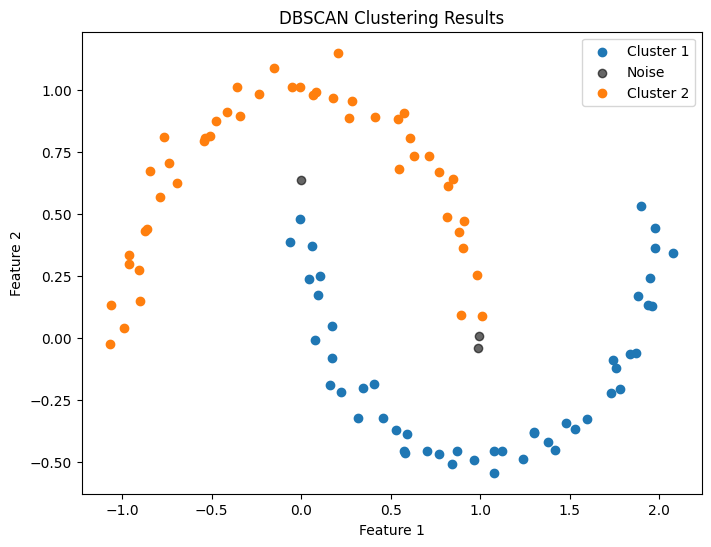

In [19]:
# Plot the points with different colors based on the cluster assignments
plt.figure(figsize=(8, 6))

# Get unique cluster labels
unique_labels = s_cluster_assignments.unique()

# Plot each cluster
for label in unique_labels:
    # Get the data points for this label (excluding noise points labeled as 0)
    cluster_points = df_dbscan[s_cluster_assignments == label]
    
    if label == 0:
        # Noise points (label 0) will be plotted in black
        plt.scatter(cluster_points.iloc[:, 0], cluster_points.iloc[:, 1], color='k', label="Noise", alpha=0.6)
    else:
        # Other clusters will have different colors
        plt.scatter(cluster_points.iloc[:, 0], cluster_points.iloc[:, 1], label=f"Cluster {label}")

# Label the axes and give the plot a title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clustering Results')

# Show the legend
plt.legend()

# Show the plot
plt.show()

## Q2.5 Compare your results to the scikit-learn library

Import DBSCAN from scikit-learn and compare the cluster labels from your implementation to the cluster labels generated from [scikit-learn's DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html). Add some commentary about how you think the results compare. Use the same data and values for eps and minPts.

In [20]:
from sklearn.cluster import DBSCAN

# Set the same eps and minPts
eps = 0.23
min_pts = 6

# Apply DBSCAN using scikit-learn
sklearn_dbscan = DBSCAN(eps=eps, min_samples=min_pts)
sklearn_labels = sklearn_dbscan.fit_predict(df_dbscan)

# Check the cluster labels from both implementations
print("Your DBSCAN implementation labels:")
print(s_cluster_assignments)
print("\nScikit-learn DBSCAN labels:")
print(sklearn_labels)

# Compare the labels - note that your DBSCAN implementation assigns '0' for noise, 
# and sklearn also uses 'label=-1' for noise.
# We can replace -1 with 0 for a fair comparison.
sklearn_labels_corrected = sklearn_labels.copy()
sklearn_labels_corrected[sklearn_labels_corrected == -1] = 0

# Check how many labels match
matching_labels = (s_cluster_assignments == sklearn_labels_corrected)

# Print out the number of matches
print("\nNumber of matching labels:", matching_labels.sum())
print("Total number of points:", len(df_dbscan))

# Comment on the comparison
if matching_labels.all():
    print("\nBoth implementations match perfectly!")
else:
    print("\nThere are some differences between the two implementations.")

Your DBSCAN implementation labels:
0     1
1     1
2     1
3     1
4     1
     ..
95    2
96    2
97    2
98    2
99    2
Length: 100, dtype: int64

Scikit-learn DBSCAN labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 -1  1  0 -1  1  0  1  1  0  1  0  1  0  0  0
  0  0  1  1  1  1  0  1  0  0  0  1  1  1  0  1  0  1  0 -1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1]

Number of matching labels: 3
Total number of points: 100

There are some differences between the two implementations.


your obervations about scikit-learn's performance vs your implementation's performance here